In [1]:
# !pip uninstall torch torchvision torchaudio -y
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [2]:
import torch
import torchvision.transforms.v2 as tfs
import torch.utils.data as data
import torch.optim as optim
import torch.nn as nn
import torchvision.models as models

from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [3]:
class DataSetSegmentation(data.Dataset):
    def __init__(self, train=True, transform=None):
        self.train = train
        self.transform = transform

        if train:
            data_list = sorted(os.listdir('/kaggle/input/competitions/estonian-land-use-semantic-segmentation-for-dl-cv-25/kaggle_upload_public/train_images'))
            target_list = sorted(os.listdir('/kaggle/input/competitions/estonian-land-use-semantic-segmentation-for-dl-cv-25/kaggle_upload_public/train_masks'))
            self.data_path = [os.path.join('/kaggle/input/competitions/estonian-land-use-semantic-segmentation-for-dl-cv-25/kaggle_upload_public/train_images', x) for x in data_list]
            self.target_path = [os.path.join('/kaggle/input/competitions/estonian-land-use-semantic-segmentation-for-dl-cv-25/kaggle_upload_public/train_masks', x) for x in target_list]
            self.length = len(data_list)
        else:
            test_list = sorted(os.listdir('/kaggle/input/competitions/estonian-land-use-semantic-segmentation-for-dl-cv-25/kaggle_upload_public/test_images'))
            self.data_path = [os.path.join('/kaggle/input/competitions/estonian-land-use-semantic-segmentation-for-dl-cv-25/kaggle_upload_public/test_images', x) for x in test_list]
            self.length = len(test_list)

    def __getitem__(self, index):
        img = Image.open(self.data_path[index]).convert('RGB')
        img = np.array(img)
    
        if self.train:
            mask = Image.open(self.target_path[index])
            mask = np.array(mask)
            if mask.ndim == 3:
                mask = mask[:, :, 0]
            augmented = self.transform(image=img, mask=mask)
            # Приводим маску к long
            return augmented['image'], augmented['mask'].long()
        else:
            augmented = self.transform(image=img)
            return augmented['image']

    def __len__(self):
        return self.length

In [4]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),                      # отражение по горизонтали
    A.RandomRotate90(p=0.3),                     # поворот на 90/180/270°
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.3
    ),                                           # изменение яркости/контраста
    A.GaussNoise(std_range=(0.04, 0.2), p=0.2), # гауссовский шум
    # A.RandomResizedCrop(size=(256,256), scale=(0.8,1.0), p=0.5), # опционально
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),                                # в тензор PyTorch
])

val_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


full_train_dataset = DataSetSegmentation(train=True, transform=train_transform)

# Полный датасет без аугментаций (для валидации)
full_val_dataset = DataSetSegmentation(train=True, transform=val_transform)

# Размеры
total_len = len(full_train_dataset)
train_size = int(0.9 * total_len)   # 90% для обучения
val_size = total_len - train_size   # 10% для валидации

# Получаем случайные индексы
indices = list(range(total_len))
import random
random.seed(42)   # для воспроизводимости
random.shuffle(indices)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Создаём Subset'ы с соответствующими трансформациями
from torch.utils.data import Subset
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_val_dataset, val_indices)

# Тестовый датасет
test_dataset = DataSetSegmentation(train=False, transform=test_transform)

In [5]:
def compute_miou(model, dataloader, device, num_classes=5):
    model.eval()
    iou_per_class = []
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)  # (B, H, W), long
            outputs = model(images)   # (B, C, H, W)
            preds = torch.argmax(outputs, dim=1)  # (B, H, W)
            
            # Для каждого класса считаем IoU
            for cls in range(num_classes):
                pred_mask = (preds == cls)
                true_mask = (masks == cls)
                intersection = (pred_mask & true_mask).sum().float()
                union = (pred_mask | true_mask).sum().float()
                if union == 0:
                    iou = torch.tensor(1.0) if intersection == 0 else torch.tensor(0.0)
                else:
                    iou = intersection / union
                iou_per_class.append(iou.item())
    # Усредняем по всем классам и по всем батчам
    iou_per_class = np.array(iou_per_class).reshape(-1, num_classes)
    miou = iou_per_class.mean(axis=0).mean()
    return miou

In [6]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        """
        Args:
            in_channels:  входные каналы для ConvTranspose2d (из нижнего уровня)
            skip_channels: каналы от skip-соединения (с энкодера)
            out_channels:  выходные каналы после двух свёрток
        """
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # После конкатенации будет out_channels + skip_channels
        self.conv_block = nn.Sequential(
            nn.Conv2d(out_channels + skip_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.up(x)                     # (batch, out_channels, H*2, W*2)
        # Если размеры чуть-чуть не совпадают (из-за нечётности), обрезаем skip
        if x.shape[2:] != skip.shape[2:]:
            diff_h = skip.shape[2] - x.shape[2]
            diff_w = skip.shape[3] - x.shape[3]
            skip = skip[:, :, diff_h//2 : diff_h//2 + x.shape[2],
                                 diff_w//2 : diff_w//2 + x.shape[3]]
        x = torch.cat([x, skip], dim=1)    # (batch, out_channels + skip_channels, ...)
        return self.conv_block(x)


class UNetWithResNet50(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        # Загружаем предобученный ResNet50
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Энкодер (берём только свёрточные части, без avgpool и fc)
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1   # 256 каналов, размер /4
        self.layer2 = resnet.layer2   # 512 каналов, размер /8
        self.layer3 = resnet.layer3   # 1024 канала, размер /16
        self.layer4 = resnet.layer4   # 2048 каналов, размер /32

        # Декодер (апсемплинг + конкатенация)
        # Вход: из layer4 (2048 каналов) -> up к layer3 (1024 skip)
        self.dec1 = DecoderBlock(in_channels=2048, skip_channels=1024, out_channels=1024)
        self.dec2 = DecoderBlock(in_channels=1024, skip_channels=512,  out_channels=512)
        self.dec3 = DecoderBlock(in_channels=512,  skip_channels=256,  out_channels=256)
        self.dec4 = DecoderBlock(in_channels=256,  skip_channels=64,   out_channels=64)  

        # Финальные слои: добиваем до исходного размера и делаем классификацию
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, 1)
        )

    def forward(self, x):
        # ---- Энкодер (ResNet50) ----
        # Слой 0 (stem)
        x = self.conv1(x)      # (batch, 64, H/2, W/2)
        x = self.bn1(x)
        x = self.relu(x)
        skip0 = x              # сохраняем для последнего декодера (64 канала, размер H/2)
        x = self.maxpool(x)    # (batch, 64, H/4, W/4)

        # Residual блоки
        s1 = self.layer1(x)    # (batch, 256, H/4, W/4)
        s2 = self.layer2(s1)   # (batch, 512, H/8, W/8)
        s3 = self.layer3(s2)   # (batch, 1024, H/16, W/16)
        s4 = self.layer4(s3)   # (batch, 2048, H/32, W/32)

        # ---- Декодер ----
        d1 = self.dec1(s4, s3)   # (1024, H/16)
        d2 = self.dec2(d1, s2)   # (512, H/8)
        d3 = self.dec3(d2, s1)   # (256, H/4)
        d4 = self.dec4(d3, skip0) # (64, H/2)

        # ---- Финальное восстановление до HxW ----
        out = self.final_up(d4)   # (32, H, W)
        out = self.final_conv(out) # (num_classes, H, W)
        return out

In [9]:
batch_size = 32
num_workers = 2  # подберите под своё железо

train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                          num_workers=num_workers, pin_memory=True)
val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetWithResNet50(num_classes=5).to(device)
# model.load_state_dict(torch.load(best_model_path))
# print(f'Best model loaded with val loss = {best_val_loss:.4f}')

# Заморозка всех слоёв по умолчанию
for name, param in model.named_parameters():
    param.requires_grad = False

# Размораживаем layer3, layer4 и все слои декодера
for name, param in model.named_parameters():
    if any(layer in name for layer in ['layer3', 'layer4', 'dec', 'final_up', 'final_conv']):
        param.requires_grad = True

# Группировка параметров с разными LR
# Параметры энкодера (размороженные слои ResNet – layer3 и layer4)
encoder_finetune_params = [p for n, p in model.named_parameters() 
                           if p.requires_grad and ('layer3' in n or 'layer4' in n)]
# Параметры декодера (всё остальное, что разморожено)
decoder_params = [p for n, p in model.named_parameters() 
                  if p.requires_grad and not ('layer3' in n or 'layer4' in n)]

optimizer = optim.RMSprop([
    {'params': decoder_params, 'lr': 1e-3},
    {'params': encoder_finetune_params, 'lr': 1e-5}
])

# Веса классов для борьбы с дисбалансом
class_freq = [0.278, 0.11, 0.358, 0.125, 0.129]  # фон, лес, дороги, вода, здания
class_weights = torch.tensor([1.0/f for f in class_freq]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Параметры обучения
epochs = 35   # оптимальное количество для такого размера данных (можно увеличить до 20-25)
best_val_loss = float('inf')
best_model_path = 'best_model.pth'

# Для хранения истории
train_losses = []
val_losses = []
val_mious = []

for epoch in range(epochs):
    # ---------- Train ----------
    model.train()
    train_loss = 0.0
    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=True)
    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=loss.item())
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    # Вычисляем mIoU на валидации
    miou = compute_miou(model, val_loader, device, num_classes=5)
    val_mious.append(miou)

    print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mIoU: {miou:.4f}')
    
    # Сохраняем лучшую модель по валидационной потере
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f'  -> Saved best model (val loss = {val_loss:.4f})')

Epoch 1/10:   1%|▏         | 7/488 [00:04<05:30,  1.45it/s, loss=1.27]


KeyboardInterrupt: 

In [10]:
best_model_path = "/kaggle/input/models/viktor1709/model/pytorch/default/1/best_model (2).pth"
model.load_state_dict(torch.load(best_model_path))
print(f'Best model loaded with val loss = {best_val_loss:.4f}')

Best model loaded with val loss = inf


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(25, 35), train_losses, label='Train Loss', marker='o')
plt.plot(range(25, 35), val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(25, 35), val_mious, label='Val mIoU', marker='^', color='green')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.title('Validation mIoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [ ]:
import pandas as pd


# ---------- ФУНКЦИЯ RLE ----------
def rle_multiclass_encode(mask):
    """Encode mask as repeated 'value start length' triplets (1-indexed, column-major)."""
    pixels = mask.flatten(order='F')
    if pixels.size == 0:
        return ""

    parts = []
    run_val = int(pixels[0])
    run_start = 1
    run_len = 1

    for idx in range(1, pixels.size):
        val = int(pixels[idx])
        if val == run_val:
            run_len += 1
        else:
            parts.append(f"{run_val} {run_start} {run_len}")
            run_val = val
            run_start = idx + 1
            run_len = 1

    parts.append(f"{run_val} {run_start} {run_len}")
    return " ".join(parts)


# ---------- НАСТРОЙКИ ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_WORKERS = 2

# Создаём test_loader из ранее созданного test_dataset
# Предполагается, что test_dataset уже определён:
# test_dataset = DataSetSegmentation(train=False, transform=test_transform)

test_loader = data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Загружаем модель (если ещё не загружена)
# model = UNetWithResNet50(num_classes=5).to(DEVICE)
# model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

# ---------- ПОЛУЧАЕМ ID ИЗОБРАЖЕНИЙ ----------
if hasattr(test_dataset, 'data_path'):
    image_ids = [os.path.splitext(os.path.basename(p))[0] for p in test_dataset.data_path]
else:
    image_ids = [f"test_{i}" for i in range(len(test_dataset))]

# ---------- ИНФЕРЕНС ----------
rows = []
with torch.no_grad():
    for i, batch_images in enumerate(tqdm(test_loader, desc="Inference")):
        batch_images = batch_images.to(DEVICE)
        logits = model(batch_images)
        preds = torch.argmax(logits, dim=1).cpu().numpy().astype(np.uint8)

        for j in range(preds.shape[0]):
            mask = preds[j]
            rle_str = rle_multiclass_encode(mask)
            rows.append({
                'Id': image_ids[i * BATCH_SIZE + j],
                'Predicted': rle_str
            })

# ---------- СОХРАНЯЕМ CSV ----------
submission_df = pd.DataFrame(rows)
submission_path = "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"✅ Сабмишн сохранён в '{submission_path}'")
print(f"   Количество записей: {len(submission_df)}")
print("   Первые 2 строки:")
print(submission_df.head(2))

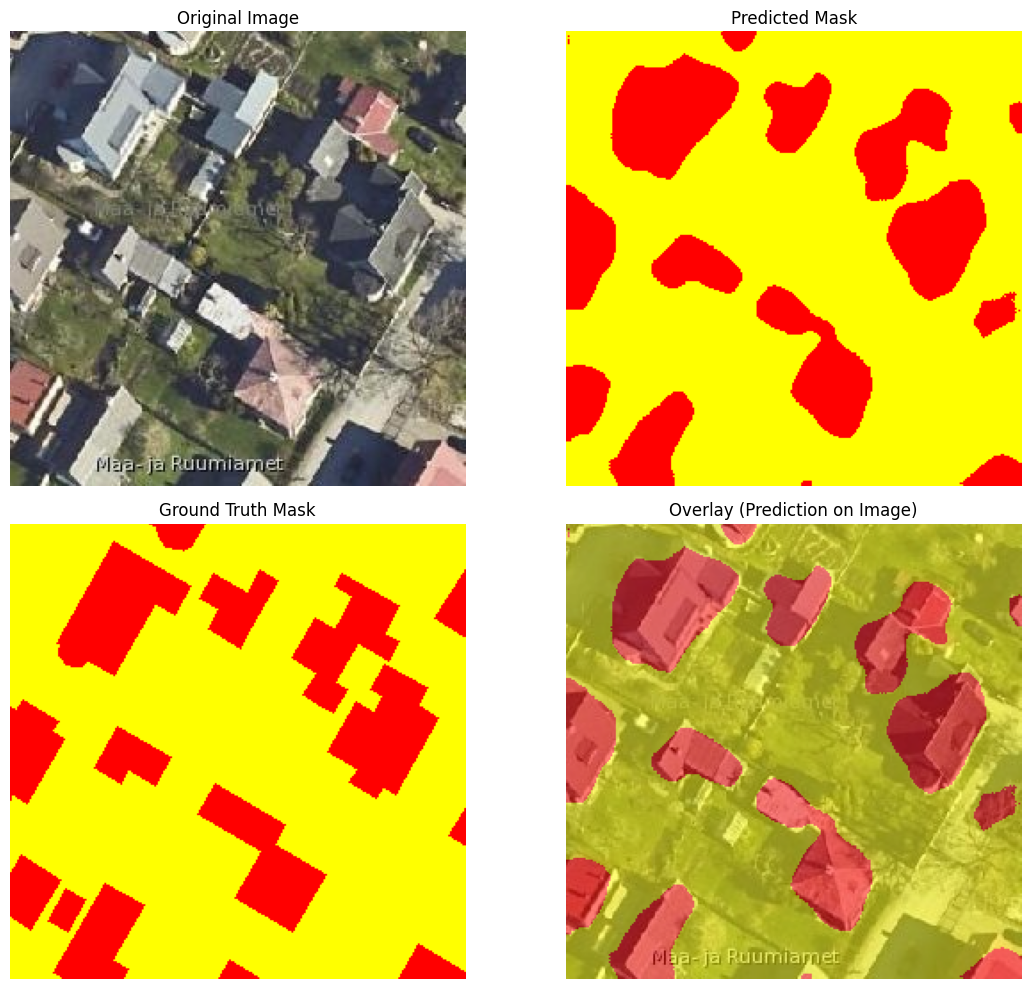

In [61]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# Функция денормализации
def denormalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    image = image_tensor.clone().detach().cpu()
    for t, m, s in zip(image, mean, std):
        t.mul_(s).add_(m)
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return image

# Цвета классов (0 - фон, 1 - здания, 2 - деревья, 3 - вода, 4 - дороги)
class_colors = np.array([
    [128, 128, 128],   # фон – серый
    [255, 0, 0],       # здания – красный
    [0, 255, 0],       # деревья – зелёный
    [0, 0, 255],       # вода – синий
    [255, 255, 0]      # дороги – жёлтый
], dtype=np.uint8)

def mask_to_color(mask):
    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in enumerate(class_colors):
        color_mask[mask == class_id] = color
    return color_mask

def overlay_mask(image, mask, alpha=0.5):
    color_mask = mask_to_color(mask)
    overlay = (image * 255).astype(np.uint8)
    blended = cv2.addWeighted(overlay, 1 - alpha, color_mask, alpha, 0)
    return blended

# Получаем батч из валидационного загрузчика
val_iter = iter(val_loader)
images, true_masks = next(val_iter)

# Выбираем нужный индекс (например, 0-й элемент)
idx = 25 
image = images[idx]          # (C, H, W)
true_mask = true_masks[idx]  # (H, W)

# Предсказание модели
model.eval()
with torch.no_grad():
    image_batch = image.unsqueeze(0).to(device)
    logits = model(image_batch)
    pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

# Денормализуем изображение
image_np = denormalize(image)

# Цветные маски
pred_color = mask_to_color(pred_mask)
true_color = mask_to_color(true_mask.cpu().numpy())

# Наложение
overlay_img = overlay_mask(image_np, pred_mask, alpha=0.5)

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(image_np)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(pred_color)
axes[0, 1].set_title('Predicted Mask')
axes[0, 1].axis('off')

axes[1, 0].imshow(true_color)
axes[1, 0].set_title('Ground Truth Mask')
axes[1, 0].axis('off')

axes[1, 1].imshow(overlay_img)
axes[1, 1].set_title('Overlay (Prediction on Image)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()